VAE

In [1]:
import torch 
import torch.nn as nn

class VAE(nn.Module):

    def __init__(self, num_channels=1, num_classes=10, latent_dim=2, embed_dim=16):
        super(VAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.embedding = nn.Embedding(num_embeddings=num_classes, embedding_dim=embed_dim)

        self.encoder = nn.ModuleList([
            nn.Conv2d(in_channels=num_channels, out_channels=8, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1),
        ])

        self.decoder = nn.ModuleList([
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
            nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3),
            nn.Conv2d(in_channels=8, out_channels=num_channels, kernel_size=3, padding=1),
        ])
        self.fc_latent = nn.Linear(in_features=latent_dim + embed_dim, out_features=512)

        self.fc_mean = nn.Linear(in_features=512 + embed_dim, out_features=latent_dim)
        self.fc_var = nn.Linear(in_features=512 + embed_dim, out_features=latent_dim)
        self.leaky_relu = nn.LeakyReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, y):
        """
        Args:
            x (tensor): Image(s) of shape [B, C, H, W].
            y (tensor): Class label(s) of shape [B,].

        Returns:
            x_recon (tensor): Reconstructed image(s) of shape [B, C, H, W].
            mean (tensor): Mean of shape [B, latent_dim]. 
            log_var (tensor): Log variance of shape [B, latent_dim].
        """
        mean, log_var = self.encode(x, y)
        # Reparameterization Trick
        eps = torch.randn(log_var.shape, device=log_var.device)
        z = mean + torch.exp(log_var * 0.5) * eps
        x_recon = self.decode(z, y)
        return x_recon, mean, log_var

    def encode(self, x, y):
        """
        Args:
            x (tensor): Image(s) of shape [B, C, H, W].
            y (tensor): Class label(s) of shape [B,].

        Returns:
            mean (tensor): Mean of shape [B, latent_dim]. 
            log_var (tensor): Log variance of shape [B, latent_dim].
        """
        for layer in self.encoder:
            x = layer(x)
            x = self.leaky_relu(x)
        x = torch.reshape(x, (x.shape[0], -1))
        class_embed = self.embedding(y)
        # Concat class information
        mean = self.fc_mean(torch.cat((x, class_embed), dim=1))
        log_var = self.fc_var(torch.cat((x, class_embed), dim=1))
        return mean, log_var

    def decode(self, z, y):
        """
        Args:
            z (tensor): Latent variable(s) of shape [B, latent_dim].
            y (tensor): Class label(s) of shape [B,].

        Returns:
            x (tensor): Reconstructed image(s) of shape [B, C, H, W].
        """
        class_embed = self.embedding(y)
        # Concat class information
        x = self.fc_latent(torch.cat((z, class_embed), dim=1))
        x = torch.reshape(x, (-1, 32, 4, 4))
        for layer in self.decoder:
            x = nn.functional.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            x = self.leaky_relu(x)
            x = layer(x)
        x = self.sigmoid(x)
        return x

    def sample(self, y, device):
        """
        Args:
            y (int): Class label.
            device (torch.device): Which device to use (cuda or cpu).

        Returns:
            (tensor): Image of shape [1, C, H, W].
        """
        z = torch.randn((1, self.latent_dim), device=device)
        return self.decode(z, torch.tensor([y], device=device))

    def sample_latent(self, x, y):
        """
        Args:
            x (tensor): Image(s) of shape [B, C, H, W].
            y (tensor): Class label(s) of shape [B,].

        Returns:
            z (tensor): Latent variable(s) of shape [B, latent_dim].
        """
        mean, log_var = self.encode(x, y)
        # Reparameterization Trick
        eps = torch.randn(log_var.shape, device=log_var.device)
        z = mean + torch.exp(log_var * 0.5) * eps
        return z

Task 1

100.0%
100.0%
100.0%
100.0%


Epoch 1 complete. Average Loss: 181.9835


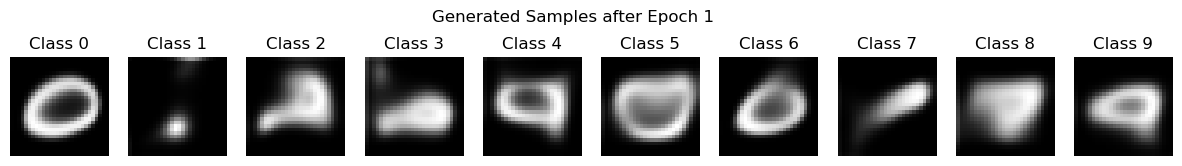

Epoch 2 complete. Average Loss: 136.9265


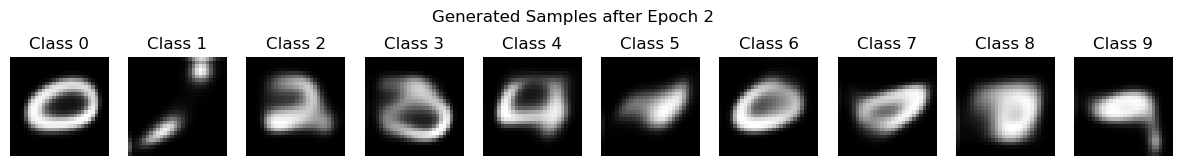

Epoch 3 complete. Average Loss: 133.6686


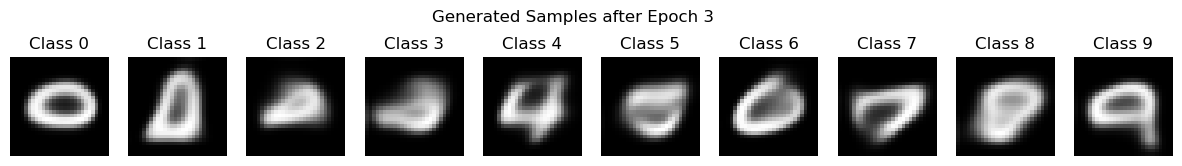

Epoch 4 complete. Average Loss: 132.2792


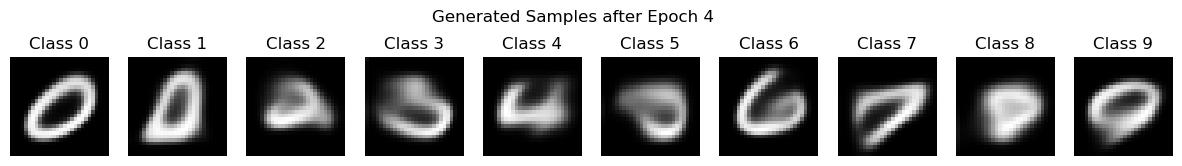

Epoch 5 complete. Average Loss: 131.4261


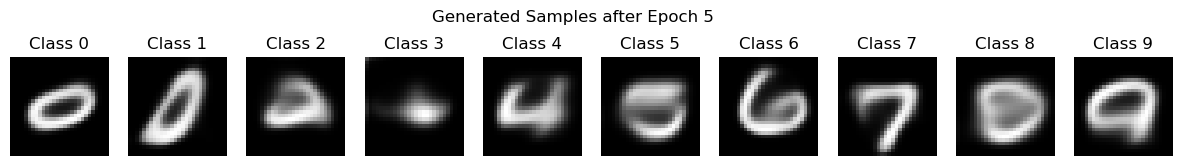

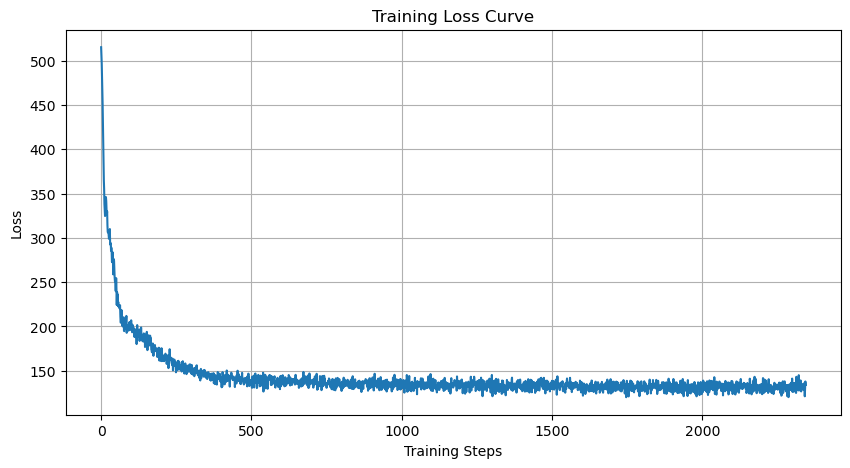

In [2]:
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
learning_rate = 0.001
kl_weight = 0.0001
epochs = 5 
latent_dim = 2

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate) 

def vae_loss(x_recon, x, mean, log_var, kl_weight):
    """
    Implements the loss function from Eq. 1
    """
    
    recon_loss = nn.functional.binary_cross_entropy(x_recon, x, reduction='sum')
    
    kl_loss = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    
    return recon_loss + kl_weight * kl_loss

train_losses = []

def train():
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0
        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)
            
            optimizer.zero_grad()
            recon_batch, mean, log_var = model(data, labels)
            
            loss = vae_loss(recon_batch, data, mean, log_var, kl_weight)
            loss.backward()
            
            optimizer.step()
            
            total_loss += loss.item()
            train_losses.append(loss.item() / len(data))
            
        avg_loss = total_loss / len(train_loader.dataset)
        print(f"Epoch {epoch} complete. Average Loss: {avg_loss:.4f}")
        
        plot_samples(epoch)

# 6. Visualization Functions
def plot_samples(epoch):
    """Plots one sample for each class (0-9) """
    model.eval()
    plt.figure(figsize=(15, 2))
    with torch.no_grad():
        for i in range(10):
            sample = model.sample(i, device).cpu().squeeze()
            plt.subplot(1, 10, i + 1)
            plt.imshow(sample, cmap='gray')
            plt.axis('off')
            plt.title(f"Class {i}")
    plt.suptitle(f"Generated Samples after Epoch {epoch}")
    plt.show()

def plot_training_curve():
    """Plots the loss over training steps"""
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses)
    plt.title("Training Loss Curve")
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

train()
plot_training_curve()

Task 2


--- Starting Experiment: Task 2.1: Reconstruction Loss Only ---
Epoch 1 finished.
Epoch 2 finished.
Epoch 3 finished.
Epoch 4 finished.
Epoch 5 finished.


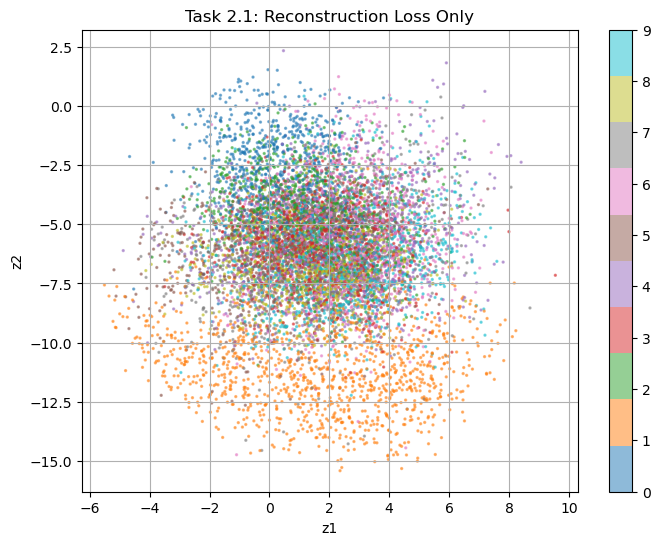


--- Starting Experiment: Task 2.2: KL Divergence Only ---
Epoch 1 finished.
Epoch 2 finished.
Epoch 3 finished.
Epoch 4 finished.
Epoch 5 finished.


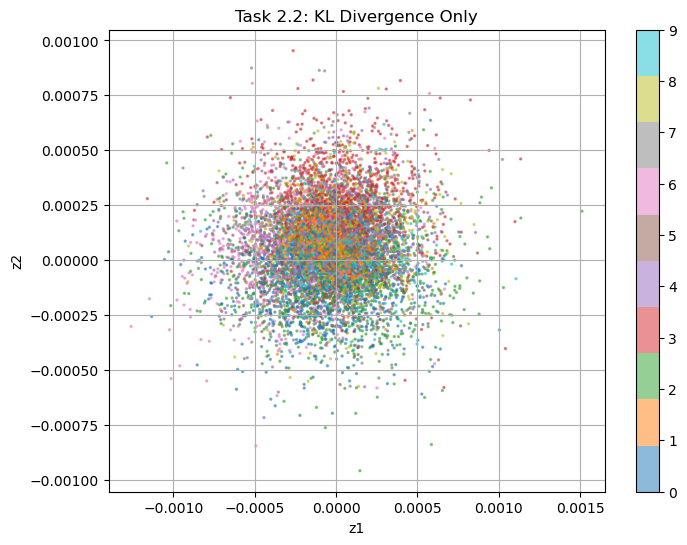


--- Starting Experiment: Task 2.3: Full Loss Function ---
Epoch 1 finished.
Epoch 2 finished.
Epoch 3 finished.
Epoch 4 finished.
Epoch 5 finished.


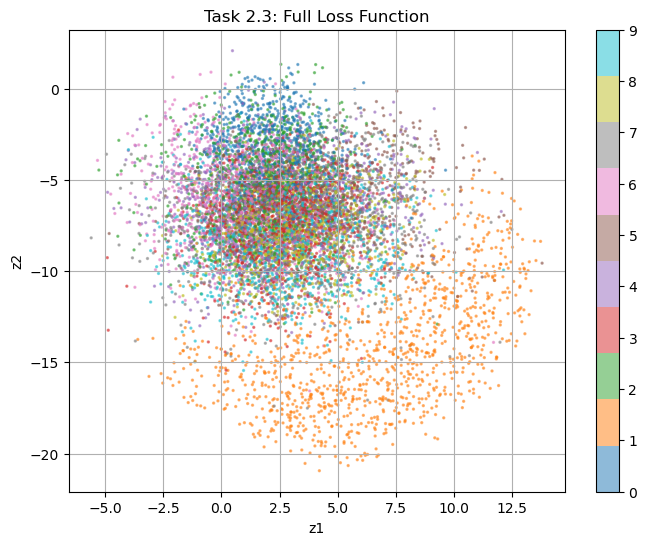

In [3]:
import matplotlib.pyplot as plt

test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

def visualize_latent_space(model, title):
    """
    Embeds the test set into 2D and creates a scatter plot.
    Points are colored by their digit class (0-9).
    """
    model.eval()
    latents = []
    labels_list = []
    
    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            mu, _ = model.encode(data, labels) 
            latents.append(mu.cpu().numpy())
            labels_list.append(labels.cpu().numpy())
            
    latents = np.concatenate(latents, axis=0)
    labels_list = np.concatenate(labels_list, axis=0)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels_list, cmap='tab10', alpha=0.5, s=2)
    plt.colorbar(scatter, ticks=range(10))
    plt.title(title)
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.grid(True)
    plt.show()

def train_specific_variant(loss_mode, title):
    """
    Trains a fresh model based on the specific Task requirements.
    """
    print(f"\n--- Starting Experiment: {title} ---")
    model_variant = VAE(latent_dim=2).to(device)
    optimizer_variant = optim.Adam(model_variant.parameters(), lr=0.001)
    
    model_variant.train()
    for epoch in range(1, 6): 
        for data, labels in train_loader:
            data, labels = data.to(device), labels.to(device)
            optimizer_variant.zero_grad()
            
            recon, mu, log_var = model_variant(data, labels)
            
            recon_loss = nn.functional.binary_cross_entropy(recon, data, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            
            if loss_mode == 'recon_only':
                loss = recon_loss # Task 2.1 
            elif loss_mode == 'kl_only':
                loss = kl_loss    # Task 2.2 
            else:
                loss = recon_loss + (0.0001 * kl_loss) # Task 2.3 
                
            loss.backward()
            optimizer_variant.step()
            
        print(f"Epoch {epoch} finished.")
    
    visualize_latent_space(model_variant, title)

train_specific_variant('recon_only', "Task 2.1: Reconstruction Loss Only")
train_specific_variant('kl_only', "Task 2.2: KL Divergence Only")
train_specific_variant('full', "Task 2.3: Full Loss Function")

Task 3

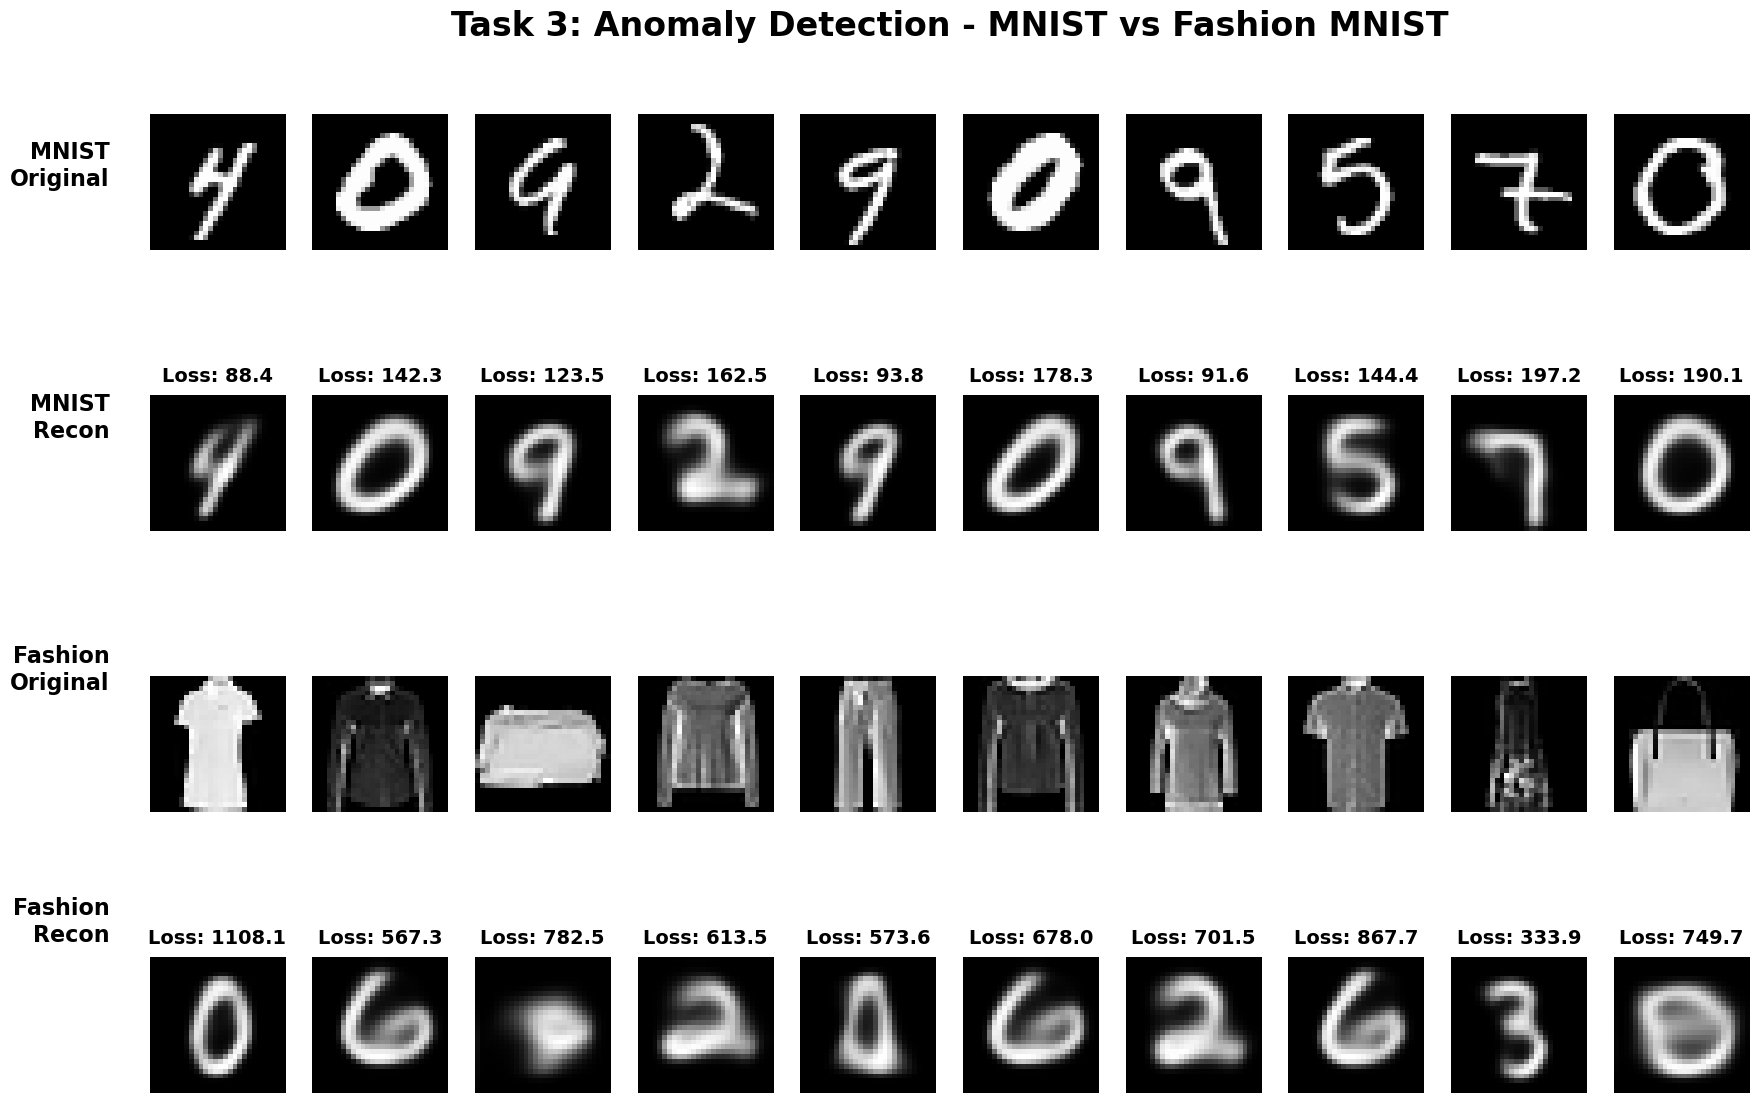

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

fashion_test = datasets.FashionMNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)
fashion_loader = DataLoader(fashion_test, batch_size=10, shuffle=True)
mnist_test = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)
mnist_loader = DataLoader(mnist_test, batch_size=10, shuffle=True)

def run_anomaly_detection_final(model, device):
    model.eval()
    m_imgs, m_labels = next(iter(mnist_loader))
    f_imgs, f_labels = next(iter(fashion_loader))
    
    fig, axes = plt.subplots(4, 10, figsize=(20, 12))
    fig.suptitle('Task 3: Anomaly Detection - MNIST vs Fashion MNIST', fontsize=24, fontweight='bold', y=0.98)
    
    datasets_list = [(m_imgs, m_labels, 0, "MNIST"), (f_imgs, f_labels, 2, "Fashion")]
    
    for imgs, labels, row, name in datasets_list:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad():
            recon, _, _ = model(imgs, labels)
            for i in range(10):
                loss = nn.functional.binary_cross_entropy(recon[i], imgs[i], reduction='sum').item()
                
                axes[row, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
                axes[row, i].axis('off')
                
                axes[row + 1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
                axes[row + 1, i].axis('off')
                axes[row + 1, i].set_title(f"Loss: {loss:.1f}", fontsize=14, fontweight='bold', pad=10)

        fig.text(0.08, 0.85 - (row * 0.21), f"{name}\nOriginal", fontsize=16, fontweight='bold', ha='right', va='center')
        fig.text(0.08, 0.64 - (row * 0.21), f"{name}\nRecon", fontsize=16, fontweight='bold', ha='right', va='center')
    
    plt.subplots_adjust(left=0.1, top=0.92, bottom=0.05, hspace=0.4)
    plt.show()

run_anomaly_detection_final(model, device)